# IPN Cross-Correlation with Time-shifted GBM Lightcurves

This notebook demonstrates how to calculate an IPN localization using three GRB lightcurves from Fermi-GBM. In this tutorial, we will assume that each GBM lightcurve was observed by a different spacecraft and will input the relative time-shift ourselves.

The overall workflow is very similar to `CCF_Example2.ipynb`: we load the lightcurves, bin them, fit backgrounds, assign spacecraft positions, measure the relative time delays with the CCF, and then convert those delays into localization annuli. The main differences are that here we use explicitly time-shifted GBM lightcurves as stand-ins for separate spacecraft, we fit the background with RoboLowess on a coarser time grid instead of the polynomial background model used in `CCF_Example2.ipynb`, and we finish by comparing geocentric and barycentric localizations.

To get started, run the notebook cell below to load the data:

In [10]:
import warnings
warnings.filterwarnings("ignore")
from gdt.missions.fermi.gbm.tte import GbmTte

tte_n9 = GbmTte.open('data/glg_tte_n9_bn170206453_v00.fit')
tte_na = GbmTte.open('data/glg_tte_na_bn170206453_v00.fit')
tte_nb = GbmTte.open('data/glg_tte_nb_bn170206453_v00.fit')

## Shift the Lightcurves

The data above are the same GBM TTE files as used in `CCF_Example2.ipynb`. First, we will bin the data and shift the lightcurves in time. In the following cell, you can choose the binning timescales and how much you would like to shift the lightcurves. 

In [11]:
from gdt.core.binning.unbinned import bin_by_time
from gdt.core.data_primitives import TimeEnergyBins
from gdt.core.plot.lightcurve import Lightcurve
from gdt.missions.fermi.gbm.headers import PhaiiHeaders
from gdt.missions.fermi.gbm.phaii import Ctime

def shift_lightcurve(phaii, dt=0.):
    """Shift a lightcurve in time

    Args:
        phaii (`gdt.missions.fermi.gbm.phaii.Phaii`): lightcurve
        dt (float): amount of time you want to shift the lightcurve

    Returns:
        (`gdt.missions.fermi.gbm.phaii.Ctime`): lightcurve shifted in time
    """
    counts = phaii.data.counts
    tstart = phaii.data.tstart + dt
    tstop = phaii.data.tstop + dt
    bins = TimeEnergyBins(counts, tstart, tstop, (tstop - tstart), phaii.data.emin, phaii.data.emax)
    return Ctime.from_data(bins, headers=PhaiiHeaders(), detector=phaii.detector)

# choose the binning timescales [s]
timescale1 = 0.064
timescale2 = 0.256
timescale3 = 0.128

# bin the data
phaii1 = tte_n9.to_phaii(bin_by_time, timescale1)
phaii2 = tte_na.to_phaii(bin_by_time, timescale2)
phaii3 = tte_nb.to_phaii(bin_by_time, timescale3)

# choose how much to temporally shift lightcurve2 relative to lightcurve1
shift2 = 5.
# same as above for lightcurve 3 relative to lightcurve1
shift3 = -0.5

# shift lightcurves
phaii2 = shift_lightcurve(phaii2, dt=shift2)
phaii3 = shift_lightcurve(phaii3, dt=shift3)

## Source Intervals

Here we reuse the same source selections as in `CCF_Example2.ipynb` hence we do not show the plots. If you are using different data set you must plot the lightcurves and choose different source regions before you run the cell below.

In [15]:
# define the source intervals
src1 = (-1., 3)
src2 = (4., 8.)
src3 = (-2., 4.)
srcs = [src1, src2, src3]

# Use time span needed for the background fit
time_pad = 12.0
fit_window = (min(src[0] for src in srcs) - time_pad,
              max(src[1] for src in srcs) + time_pad)

phaii1 = phaii1.slice_time(fit_window)
phaii2 = phaii2.slice_time(fit_window)
phaii3 = phaii3.slice_time(fit_window)

phaiis = [phaii1, phaii2, phaii3]

### Fit the Background

This step plays the same role as in `CCF_Example2.ipynb`: we estimate the background for each lightcurve before running the CCF localization. The difference is the fitting strategy. `CCF_Example2.ipynb` uses explicit background intervals together with a polynomial background model, whereas here we use RoboLowess to estimate the background directly from the binned lightcurves.

To keep the fit fast, we first restrict the data to a shorter time window around the source intervals instead of fitting over the entire TTE span. We then estimate the background on a coarser time grid and interpolate that model back onto the original lightcurve bins used for the CCF.

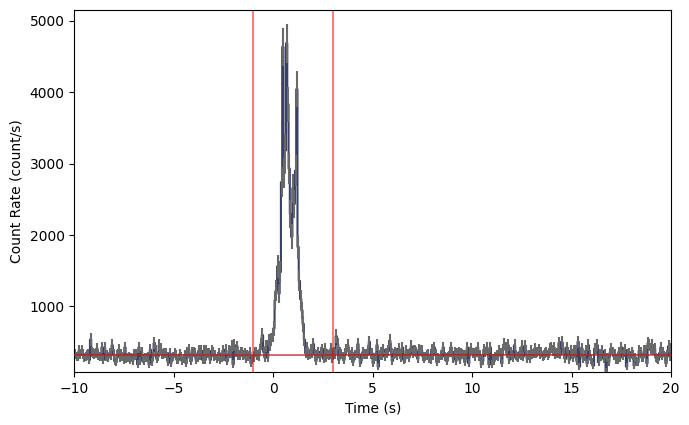

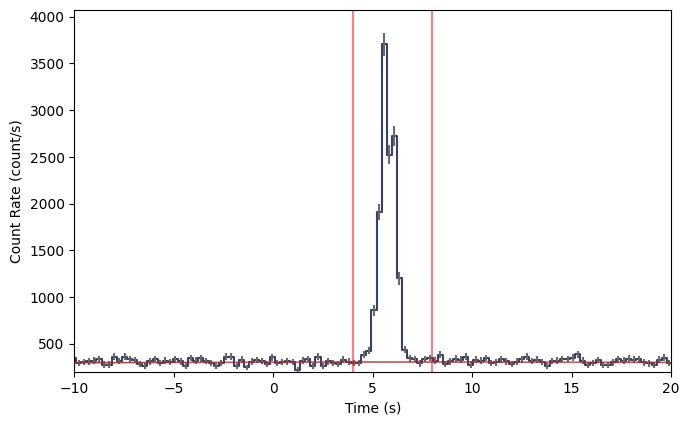

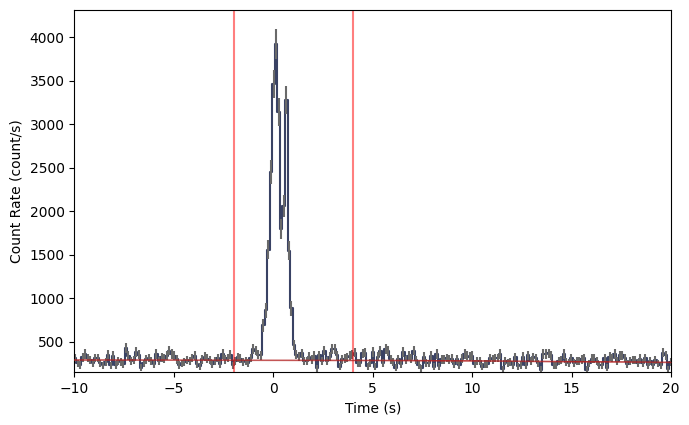

In [17]:
from gdt.core.background.binned import RoboLowess
from gdt.core.background.primitives import BackgroundRates
from gdt.core.binning.binned import rebin_by_time
import matplotlib.pyplot as plt 

# define the energy range & a coarser temporal resolution for the background fitting
energy_range = (50.0, 300.0)
common_chan_range = (33, 85)
Time_binned_bg = 1.024

def fit_background_on_coarse_bins(phaii, dt_bg):
    fine_data = phaii.data
    bg_phaii = phaii.rebin_time(rebin_by_time, dt_bg)
    bg_data = bg_phaii.data

    fitter = RoboLowess(bg_data.counts, bg_data.tstart, bg_data.tstop, bg_data.exposure,
                        first_pass_chan_range=common_chan_range)
    fitter.fit(temporal_resolution=dt_bg, min_win=0.4, max_win=0.95,
               spline_bc_type='clamped', lowess_iter=1)

    rates, rate_uncert = fitter.interpolate(fine_data.tstart, fine_data.tstop)
    bkgd_model = BackgroundRates(rates, rate_uncert, fine_data.tstart, fine_data.tstop,
                                 fine_data.emin, fine_data.emax, exposure=fine_data.exposure)
    return bg_phaii, fitter, bkgd_model

# Fit on coarser bins, then evaluate the background on the original lightcurve bins.
bg_phaiis = []
bkgd_fitters = []
bkgd_models = []

for phaii in phaiis:
    bg_phaii, bkgd_fitter, bkgd_model = fit_background_on_coarse_bins(phaii, Time_binned_bg)
    bg_phaiis.append(bg_phaii)
    bkgd_fitters.append(bkgd_fitter)
    bkgd_models.append(bkgd_model)

# plot the lightcurves
lcplots = [Lightcurve(data=phaii.to_lightcurve(energy_range=energy_range),
                     background=bkgd_model.integrate_energy(*energy_range))
                     for phaii, bkgd_model in zip(phaiis, bkgd_models)]

for lcplot, src in zip(lcplots, srcs):
    lcplot.xlim = -10, 20
    lcplot.ax.axvline(x=src[0], color='red', alpha=0.5)
    lcplot.ax.axvline(x=src[1], color='red', alpha=0.5)
plt.show()

## Spacecraft Geometry

In `CCF_Example2.ipynb`, the spacecraft positions are simple schematic examples that are sufficient to demonstrate the CCF workflow and annulus construction. Here we instead assign explicit geocentric Cartesian positions so that the recovered time delays are consistent with the artificial shifts we inserted into the lightcurves.

Using full 3D position vectors is also important for the later geocentric-versus-barycentric comparison. Once we ask how the localization changes between reference frames, we need a well-defined baseline direction in space.

In [15]:
from gdt.ipn.instrument import *

# store the lightcurves and background as observations
observations = [Observation(phaii.to_lightcurve(energy_range=energy_range),
                    background=bkgd_model.integrate_energy(*energy_range))
                        for phaii, bkgd_model in zip(phaiis, bkgd_models)]

# (~5 s for pair 1-2 and ~0.5 s for pair 1-3).
# Distances are geocentric Cartesian coordinates in km.
scpos1 = SpacecraftPosition.from_vectors([6878.0, 0.0, 0.0],
                                         [0.0, 0.0, 0.0])
scpos2 = SpacecraftPosition.from_vectors([-1.8e6, 2.0e5, 1.0e5],
                                         [0.0, 0.0, 0.0])
scpos3 = SpacecraftPosition.from_vectors([2.2e5, -1.5e5, 8.0e4],
                                         [0.0, 0.0, 0.0])

spacecraft1 = Spacecraft(scpos1)
spacecraft2 = Spacecraft(scpos2)
spacecraft3 = Spacecraft(scpos3)
spacecraft = [spacecraft1, spacecraft2, spacecraft3]
_ = [spcft.set_observation(observation) for spcft, observation in zip(spacecraft, observations)]

## Find the time delays

Now we will calculate the time delays between pairs of our lightcurves similar to what was done in `CCF_Example2.ipynb`.

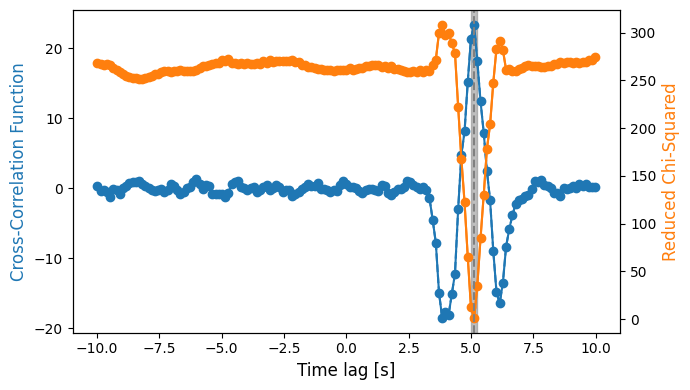

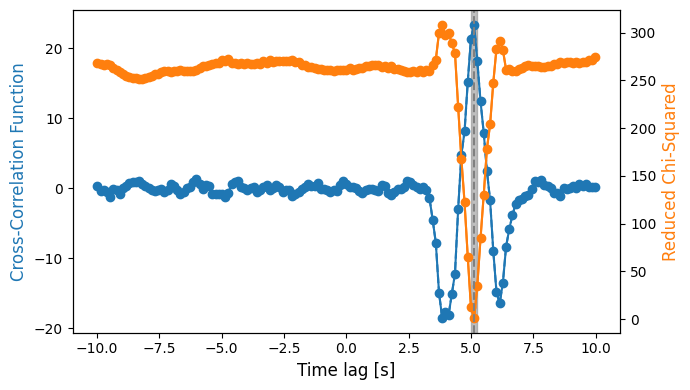

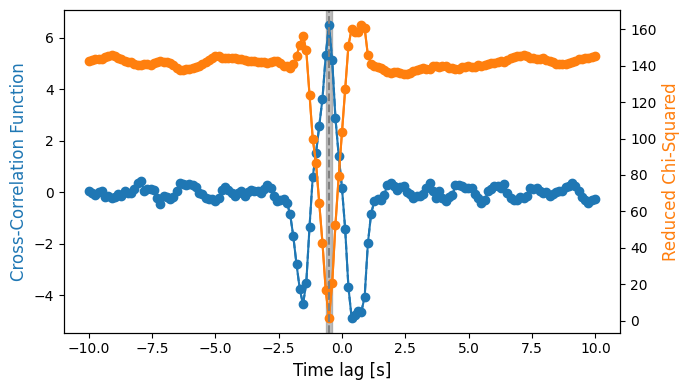

Time offset: 5.120 (+0.128, -0.128)
Time offset: -0.512 (+0.128, -0.128)


In [22]:
from gdt.ipn.algorithms.ccf import Ipn

# initialize the IPN with the lightcurve observations
ipn1 = Ipn.from_list([spacecraft1, spacecraft2]) # lightcurve 1 and lightcurve 2
ipn2 = Ipn.from_list([spacecraft1, spacecraft3]) # lightcurve 1 and lightcurve 3

# perform the time shifts
ipn1.localize(src1, src2, max_dt=10., plot=False)
ipn2.localize(src1, src3, max_dt=10., plot=False)

# plot the fit of the CCF and chisq for each time shift
ipn1.plot_fit()
ipn2.plot_fit()

# the time offset and error
print('Time offset: {0:.3f} (+{1:.3f}, -{2:.3f})'.format(ipn1.time_offset.dt, ipn1.time_offset.err[1], ipn1.time_offset.err[0]))
print('Time offset: {0:.3f} (+{1:.3f}, -{2:.3f})'.format(ipn2.time_offset.dt, ipn2.time_offset.err[1], ipn2.time_offset.err[0]))

For our first pair of lightcurves, we received a time offset very close to the true offset of +5 s. For our second pair of lightcurves, the true offset lies within the 3 sigma confidence intervals.


## Geocentric vs Barycentric Baselines

The IPN annulus is defined by the direction of the baseline vector between two spacecraft and the light-travel-time delay. By default, `get_healpix()` computes the baseline from the geocentric Cartesian positions you provided, which is the same frame used implicitly in `CCF_Example2.ipynb`. This is sufficient when all instruments are near Earth, because the geocentric and solar-system barycentric frames differ only by a small correction compared to the inter-spacecraft separation.

However, when one instrument is at an interplanetary distance the correct frame is the solar-system barycenter. In that frame, each spacecraft position must be computed as the sum of its geocentric coordinates and the position of Earth's center relative to the barycenter at the time of the observation. Because the two spacecraft observe the burst at slightly different times, their barycentric positions must be evaluated at their respective observation times.

Below, we compare the geocentric and barycentric baseline directions, generate both localizations with `ipn.get_healpix()`, and plot the barycentric annuli.

Pair 1-2 geocentric baseline (RA, Dec) = (353.684, -3.149) deg
Pair 1-2 barycentric baseline (RA, Dec) = (353.680, -3.150) deg
Pair 1-3 geocentric baseline (RA, Dec) = (144.861, -17.065) deg
Pair 1-3 barycentric baseline (RA, Dec) = (144.858, -17.064) deg
Pair 1-2 max |prob_bary - prob_geo| = 3.579e-07
Pair 1-3 max |prob_bary - prob_geo| = 1.071e-08


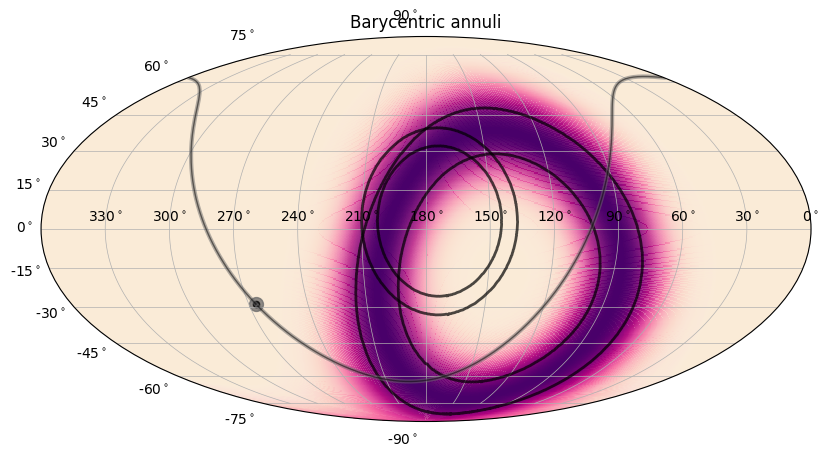

In [ ]:
from astropy.time import Time, TimeDelta
from gdt.core.plot.sky import EquatorialPlot
from gdt.core.healpix import HealPixLocalization

# set the map resolution
nside = 256

# Choose an absolute reference time near the burst.
# IPN convention: dt = t(sc1) - t(sc_other), therefore
# t(sc_other) = t(sc1) - dt
t_ref = Time('2017-02-06T10:52:14', scale='utc')

t1_12 = t_ref
t2_12 = t_ref - TimeDelta(ipn1.time_offset.dt, format='sec')
t1_13 = t_ref
t3_13 = t_ref - TimeDelta(ipn2.time_offset.dt, format='sec')

# Compare the default geocentric and barycentric baseline directions.
geo12_ra, geo12_dec = spacecraft1.baseline_to(spacecraft2)
bary12_ra, bary12_dec = spacecraft1.baseline_to(spacecraft2, obstime=t1_12, other_obstime=t2_12, barycentric=True)
geo13_ra, geo13_dec = spacecraft1.baseline_to(spacecraft3)
bary13_ra, bary13_dec = spacecraft1.baseline_to(spacecraft3, obstime=t1_13, other_obstime=t3_13, barycentric=True)

# Generate the geocentric and barycentric healpix objects.
hpx1 = ipn1.get_healpix(nside=nside)
hpx2 = ipn2.get_healpix(nside=nside)
hpx1_bary = ipn1.get_healpix(nside=nside, obstime=t1_12, other_obstime=t2_12, barycentric=True)
hpx2_bary = ipn2.get_healpix(nside=nside, obstime=t1_13, other_obstime=t3_13, barycentric=True)

print(f'Pair 1-2 geocentric baseline (RA, Dec) = ({np.rad2deg(geo12_ra):.3f}, {np.rad2deg(geo12_dec):.3f}) deg')
print(f'Pair 1-2 barycentric baseline (RA, Dec) = ({np.rad2deg(bary12_ra):.3f}, {np.rad2deg(bary12_dec):.3f}) deg')
print(f'Pair 1-3 geocentric baseline (RA, Dec) = ({np.rad2deg(geo13_ra):.3f}, {np.rad2deg(geo13_dec):.3f}) deg')
print(f'Pair 1-3 barycentric baseline (RA, Dec) = ({np.rad2deg(bary13_ra):.3f}, {np.rad2deg(bary13_dec):.3f}) deg')
print(f'Pair 1-2 max |prob_bary - prob_geo| = {np.max(np.abs(hpx1_bary.prob - hpx1.prob)):.3e}')
print(f'Pair 1-3 max |prob_bary - prob_geo| = {np.max(np.abs(hpx2_bary.prob - hpx2.prob)):.3e}')


skyplot_bary = EquatorialPlot()
skyplot_bary.add_localization(hpx1_bary, clevels=[0.90], gradient=True,
                              sun=False, earth=False, detectors=[])
skyplot_bary.add_localization(hpx2_bary, clevels=[0.68], gradient=True,
                              sun=False, earth=False, detectors=[])
plt.title('Barycentric annuli')
plt.show()
plt.close()

## Joint Localization

Here we combine the two barycentric annulus maps into a single joint probability map.

Each annulus from a detector pair constrains the source to a ring on the sky. With two independent pairs sharing a common spacecraft, we obtain two annuli whose intersection narrows the localization to two compact regions. We form the joint probability map by multiplying the two barycentric annulus maps pixel-by-pixel and renormalizing. The resulting map isolates the sky positions consistent with both time delays simultaneously.

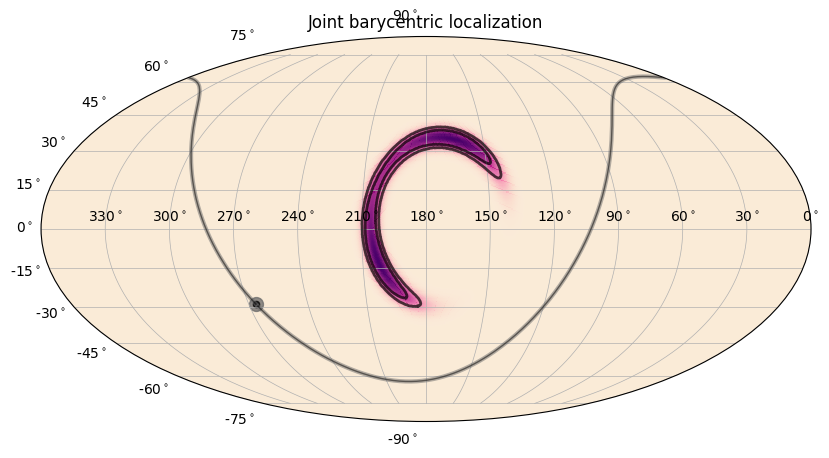

In [24]:
import healpy as hp

# Combine the barycentric annulus maps to highlight the overlap region directly.
nside = hpx1_bary.nside
prob1 = hpx1_bary.prob if hpx1_bary.nside == nside else hp.ud_grade(hpx1_bary.prob, nside_out=nside)
prob2 = hpx2_bary.prob if hpx2_bary.nside == nside else hp.ud_grade(hpx2_bary.prob, nside_out=nside)

joint_prob = prob1 * prob2
joint_prob /= joint_prob.sum()

joint_hpx = HealPixLocalization.from_data(joint_prob)

skyplot = EquatorialPlot()
skyplot.add_localization(joint_hpx, clevels=[0.68, 0.90], sun=False, earth=False, detectors=[])
plt.title('Joint barycentric localization')
plt.show()
plt.close()